In [1]:
import pandas as pd
import numpy as np
import kagglehub as kh
import os
import dotenv

c:\Users\USER\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
#load kaggle key from env file
dotenv.load_dotenv()

print(os.getenv("KAGGLE_USERNAME"))
print(os.getenv("KAGGLE_KEY"))

houzibe
KGAT_aba83c93df797a86fc0a5db11145e170


In [ ]:
#Download public synthetic upcoding health insurance claims dataset
handle = "apexsyntheticdata/synthetic-healthcare-fraud-dataset-10k"
path =  kh.dataset_download(handle)

print(path)

In [ ]:
#Access downloaded dataset
for file in os.listdir(path):
    if(file.endswith(".csv")):
        csv_read = os.path.join(path, file)
        df = pd.read_csv(csv_read)

print(df.shape)
print(df.head())

Explore dataset

In [ ]:
print("-" * 60)
print("\t\tEXPLORATORY DATA ANALYSIS")
print("-" * 60)

print(df.shape)
print(df.columns.tolist())
print("-" * 60)

#print(df.head())
print("-" * 60)

print(df["is_anomaly"].value_counts())
print(df["anomaly_type"].value_counts())
print("-" * 60)


Preprocess the Dataset

In [ ]:
#Keep labels for evaluation. It should not be used for training
X = df.drop(["is_anomaly", "anomaly_type"], axis=1) #features only
y = df["is_anomaly"] #Hidden labels for testing

#Encode categorical variables (diagnosis codes, procedures codes, etc)
from sklearn.preprocessing import  LabelEncoder
categorical_cols = X.select_dtypes(include = ["object"]).columns

for col in categorical_cols:
    X[col] = LabelEncoder().fit_transform(X[col].astype(str))

#scale numerical features
from sklearn.preprocessing import StandardScaler
num_cols = X.select_dtypes(include=["float64","int64"]).columns
X_scaled = X.copy()
X_scaled[num_cols] = StandardScaler().fit_transform(X[num_cols])

In [ ]:
from sklearn.ensemble import IsolationForest

iso_forest =  IsolationForest(
    n_estimators = 100,
    contamination = 0.05,
    random_state = 42
)

iso_forest.fit(X_scaled)
y_pred = iso_forest.predict(X_scaled)

scores = iso_forest.score_samples(X_scaled)

print(scores)

In [ ]:
from sklearn.metrics import precision_score, recall_score, confusion_matrix
y_binary = (y_pred == -1).astype(int)

print(f"Precision: {precision_score(y, y_binary)}")
print(f"Recall: {recall_score(y,y_binary)}")
print(f"Confusion Matrix: \n{confusion_matrix(y, y_binary)}")

SHAP EXPLANATIONS

In [10]:
import shap
explainer = shap.TreeExplainer(iso_forest)
shap_values = explainer.shap_values(X_scaled)

top_n = 10
top_anomaly_indices = np.argsort(scores)[:top_n]

**********************************************************************
TOP 10 ANOMALOUS CLAIMS AND WHY THEY WERE FLAGGED (UPRCODING FOCUS)
**********************************************************************

------ CLAIM INDEX: 8068 ------
Anomaly Score(raw): -0.6757 (more negative = more suspicious)

Original Claim values:
 cpt_procedure_code: 36415
 icd10_diagnosis_code: E11.9
 billed_amount: 8050.29
 patient_id: PT-f3013dff
 anomaly_type: nan

Why this claim was flagged (top 3 contributing features):
  • billed_amount: SHAP = -2.5605 → ↓ NORMAL
      → The billed amount is atypical (too high or too low for this claim type).
  • cpt_procedure_code: SHAP = -1.0783 → ↓ NORMAL
      → The procedure code is unusual relative to normal patterns.
  • claim_id: SHAP = -0.3915 → ↓ NORMAL
--------------------------------------------------

------ CLAIM INDEX: 8204 ------
Anomaly Score(raw): -0.6754 (more negative = more suspicious)

Original Claim values:
 cpt_procedure_code: 36415
 icd10_d

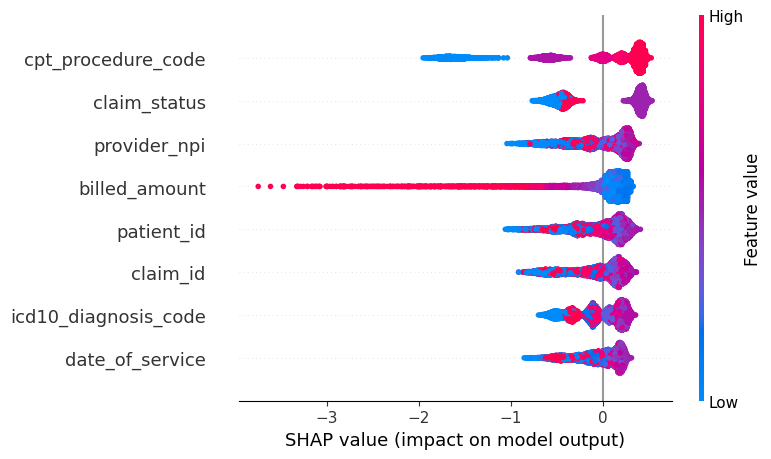

In [26]:
print("*"*70)
print(f"TOP {top_n} ANOMALOUS CLAIMS AND WHY THEY WERE FLAGGED (UPRCODING FOCUS)")
print("*"*70)

feature_names = X_scaled.columns.tolist()
for idx in top_anomaly_indices:
    print(f"\n------ CLAIM INDEX: {idx} ------")
    print(f"Anomaly Score(raw): {scores[idx]:.4f} (more negative = more suspicious)")
    #Print actual values from original data (for interpretability)
    original_df = df.copy()
    print("\nOriginal Claim values:")
    original_claim = original_df.iloc[idx]

    #print only relevant columns for upcoding
    relevant_cols = ["cpt_procedure_code", "icd10_diagnosis_code", "billed_amount", "patient_id", "length_of_stay", "anomaly_type"]

    for col in relevant_cols:
        if col in original_claim:
            print(f" {col}: {original_claim[col]}")

    #SHAP values for this specific claims
    shap_vals_for_claim = shap_values[idx]

    impact_df = pd.DataFrame({
        "feature": feature_names,
        "shap_value": shap_vals_for_claim
    })    

    impact_df["abs_shap"] = np.abs(impact_df["shap_value"])
    impact_df = impact_df.sort_values('abs_shap', ascending=False)

    print("\nWhy this claim was flagged (top 3 contributing features):")
    for i, row in impact_df.head(3).iterrows():
        feature = row["feature"]
        shap_val = row["shap_value"]
        direction = "↑ ANOMALY (more suspicious)" if shap_val > 0 else "↓ NORMAL"
        print(f"  • {feature}: SHAP = {shap_val:.4f} → {direction}")

        # Add human-readable interpretation for upcoding-related features
        if feature == 'cpt_procedure_code':
            print(f"      → The procedure code is unusual relative to normal patterns.")
        elif feature == 'billed_amount':
            print(f"      → The billed amount is atypical (too high or too low for this claim type).")
        elif feature == 'icd10_diagnosis_code':
            print(f"      → The diagnosis code deviates from typical combinations.")
    print("-" * 50)

# ------------------------------------------------------------
# 7. Global SHAP summary (which features matter most overall)
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("GLOBAL FEATURE IMPORTANCE (which features drive anomaly detection)")
print("=" * 70)
shap.summary_plot(shap_values, X_scaled, feature_names=feature_names, show=False)
# If you're in a notebook, use show=True; otherwise save the plot
import matplotlib.pyplot as plt
plt.tight_layout()
#plt.savefig('shap_summary_plot.png')
#print("Global SHAP summary plot saved as 'shap_summary_plot.png'")
